# mBERT Multi-Task ABSA — Aspect Category + Sentiment
Kiến trúc: `Input → mBERT (shared encoder) → Head 1: aspect detection → Head 2: sentiment classification`

- **Model**: `bert-base-multilingual-cased` — hỗ trợ đa ngôn ngữ, không cần word segmentation
- **Head 1**: multi-label binary classification — câu thuộc category nào?
- **Head 2**: per-category sentiment (POS / NEG / NEU) — train song song, không tuần tự


In [1]:
!pip install transformers tensorboardX tqdm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 3.3 MB/s eta 0:00:00


## 1. Config
Toàn bộ tham số dự án — chỉ chỉnh tại đây.

In [2]:
import os, sys, random, unicodedata, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, RandomSampler, SequentialSampler
from torch.optim import AdamW
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from tensorboardX import SummaryWriter
from tqdm.notebook import tqdm, trange
from sklearn.metrics import f1_score, classification_report, confusion_matrix, f1_score as sk_f1
from collections import Counter

# ── Môi trường ────────────────────────────────────────────────────────────
ON_KAGGLE   = os.path.exists('/kaggle/working')
WORKING_DIR = '/kaggle/working' if ON_KAGGLE else os.getcwd()
print('Environment:', 'Kaggle' if ON_KAGGLE else 'Local')

# ── Model ─────────────────────────────────────────────────────────────────
MODEL_NAME    = 'bert-base-multilingual-cased'   # mBERT multilingual

# ── Data ──────────────────────────────────────────────────────────────────

train1     = '/kaggle/input/datasets/conanwinner1/vku-feedback/train1.csv'
train2     = '/kaggle/input/datasets/conanwinner1/vku-feedback/train2.csv'
train3     = '/kaggle/input/datasets/conanwinner1/vku-feedback/train3.csv'
train4     = '/kaggle/input/datasets/conanwinner1/vku-feedback/train4.csv'
train5     = '/kaggle/input/datasets/conanwinner1/vku-feedback/train5.csv'
train6     = '/kaggle/input/datasets/conanwinner1/vku-feedback/train6.csv'
validation = '/kaggle/input/datasets/conanwinner1/vku-feedback/validation.csv'
test       = '/kaggle/input/datasets/conanwinner1/vku-feedback/test.csv'

# Data for multilingual
course_train      = '/kaggle/input/datasets/conanwinner1/vku-feedback/course_v2_train.csv'
course_validation = '/kaggle/input/datasets/conanwinner1/vku-feedback/course_v2_validation.csv'
course_test       = '/kaggle/input/datasets/conanwinner1/vku-feedback/course_v2_test.csv'


OUTPUT_DIR = f'{WORKING_DIR}/bert-multitask-acsa'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Aspect Categories ─────────────────────────────────────────────────────
ASPECT_CATEGORIES = [
    'ky_nang_giang_day',    # 0
    'hanh_vi',              # 1
    'de_xuat',              # 2
    'bai_tap',              # 3
    'chuong_trinh_hoc',     # 4
    'kien_thuc',            # 5
    'kinh_nghiem',          # 6
    'cung_cap_tai_lieu',    # 7
    'thiet_bi_day_hoc',     # 8
    'cham_diem',            # 9
    'noi_chung',            # 10
]
NUM_ASPECTS = len(ASPECT_CATEGORIES)
ASPECT2ID   = {a: i for i, a in enumerate(ASPECT_CATEGORIES)}
ID2ASPECT   = {i: a for i, a in enumerate(ASPECT_CATEGORIES)}

# ── Sentiment ─────────────────────────────────────────────────────────────
POLARITIES     = ['negative', 'neutral', 'positive']  # 0, 1, 2
NUM_POLARITIES = len(POLARITIES)
POL2ID         = {p: i for i, p in enumerate(POLARITIES)}
ID2POL         = {i: p for i, p in enumerate(POLARITIES)}
IGNORE_INDEX   = -100

# ── Training ──────────────────────────────────────────────────────────────
SEED             = 42
MAX_EPOCHS       = 6
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE  = 32
LEARNING_RATE    = 1e-5
WARMUP_RATIO     = 0.1
MAX_SEQ_LENGTH   = 128
WEIGHT_DECAY     = 0.05
PATIENCE         = 2      # early stopping: dừng nếu monitor không tăng sau N epochs
DROPOUT          = 0.30   # tăng regularization để giảm val loss đi lên
ASPECT_LABEL_SMOOTHING = 0.02
SENT_LABEL_SMOOTHING   = 0.05
VAL_LOSS_PENALTY       = 0.05   # phạt checkpoint khi val_loss tăng quá mạnh

# ── Multi-task loss weights ───────────────────────────────────────────────
ALPHA = 1.0
BETA  = 1.0

# ── Logging ───────────────────────────────────────────────────────────────
LOG_STEPS  = 50
SAVE_STEPS = 200

print(f'Model     : {MODEL_NAME}')
print(f'Categories: {NUM_ASPECTS}')
print(f'Output    : {OUTPUT_DIR}')


Environment: Kaggle
Model     : bert-base-multilingual-cased
Categories: 11
Output    : /kaggle/working/bert-multitask-acsa


## 2. Kiểm tra GPU

In [3]:
print('PyTorch:', torch.__version__)
print('CUDA:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
n_gpu  = torch.cuda.device_count()

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print('Tokenizer loaded:', MODEL_NAME)


PyTorch: 2.10.0+cu128
CUDA: True
GPU: Tesla T4


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded: bert-base-multilingual-cased


## 3. Data — Convert CSV → Category CSV

## 3.1. Word Segmentation (PhoBERT yêu cầu)

In [4]:
def preprocess_text(text):
    """
    Tiền xử lý cho mBERT:
    1. Chuẩn hóa Unicode NFC
    2. Trim whitespace thừa, chuẩn hóa dấu câu đầu câu
    (mBERT không cần word segmentation)
    """
    text = unicodedata.normalize('NFC', str(text).strip())
    text = re.sub(r'^[\s\.\-]+', '', text)
    return text


# Test thử
samples_test = [
    'Giảng viên rất nhiệt tình và tài năng.',
    'Phòng học quá nóng, không có điều hòa.',
    '. Thầy/cô luôn tôn trọng sinh viên.',
]
print('Preprocess examples:')
for s in samples_test:
    print(f'  Before: {s}')
    print(f'  After : {preprocess_text(s)}')
    print()


Preprocess examples:
  Before: Giảng viên rất nhiệt tình và tài năng.
  After : Giảng viên rất nhiệt tình và tài năng.

  Before: Phòng học quá nóng, không có điều hòa.
  After : Phòng học quá nóng, không có điều hòa.

  Before: . Thầy/cô luôn tôn trọng sinh viên.
  After : Thầy/cô luôn tôn trọng sinh viên.



In [5]:
df_train1 = pd.read_csv(train1)
df_train2 = pd.read_csv(train2)
df_train3 = pd.read_csv(train3)
df_train4 = pd.read_csv(train4)
df_train5 = pd.read_csv(train5)
df_train6 = pd.read_csv(train6)

df_validation = pd.read_csv(validation)
df_test = pd.read_csv(test)

# multilingual
df_course_train = pd.read_csv(course_train)
df_course_validation = pd.read_csv(course_validation)
df_course_test = pd.read_csv(course_test)

# print(df_train1.info())

In [6]:
df = pd.concat([df_train1, df_train2, df_train3, df_train4, df_train5, df_train6], ignore_index=True)

In [7]:
# df.head(5)

In [8]:
print(df.value_counts("aspect"))

aspect
ky_nang_giang_day    4546
hanh_vi              4474
de_xuat              2044
bai_tap              1241
chuong_trinh_hoc      989
kien_thuc             867
kinh_nghiem           652
cung_cap_tai_lieu     646
thiet_bi_day_hoc      564
noi_chung             546
cham_diem             314
Name: count, dtype: int64


In [9]:
print(df.value_counts("sentiment"))

sentiment
positive    8448
negative    5939
neutral     2496
Name: count, dtype: int64


In [10]:
min_len = df['text'].str.len().min()
max_len = df['text'].str.len().max()

print("Min length:", min_len)
print("Max length:", max_len)

Min length: 4
Max length: 660


In [11]:
df['text'].str.len().describe()

count    16883.000000
mean        66.861636
std         48.829144
min          4.000000
25%         35.000000
50%         53.000000
75%         83.000000
max        660.000000
Name: text, dtype: float64

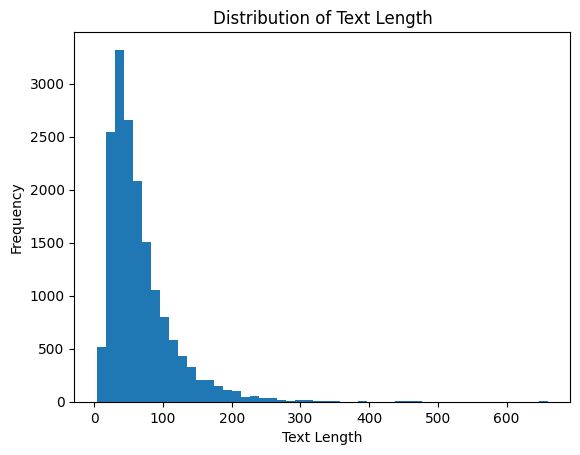

In [12]:
import matplotlib.pyplot as plt

lengths = df['text'].str.len()

plt.figure()
plt.hist(lengths, bins=50)
plt.title("Distribution of Text Length")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()

In [13]:
token_lens = []
for text in df['text']:
    processed = preprocess_text(text)   # phải preprocess trước như lúc train
    tokens = tokenizer.encode(processed, add_special_tokens=True)
    token_lens.append(len(tokens))

pd.Series(token_lens).describe()


count    16883.000000
mean        19.432506
std         12.494093
min          4.000000
25%         11.000000
50%         16.000000
75%         24.000000
max        176.000000
dtype: float64

In [14]:
import numpy as np

print("90%:", np.percentile(token_lens, 90))
print("95%:", np.percentile(token_lens, 95))
print("99%:", np.percentile(token_lens, 99))
print("max:", max(token_lens))

90%: 35.0
95%: 43.0
99%: 65.0
max: 176


In [15]:
def load_acsa_data(df_file):
    """
    Group theo id → mỗi sample:
      - text      : str (đã preprocess)
      - aspect    : (NUM_ASPECTS,) float multi-hot
      - sentiment : (NUM_ASPECTS,) int, IGNORE_INDEX nếu absent
    """
    df = df_file
    samples = []
    skipped = 0

    for sent_id, group in df.groupby('id'):
        text = preprocess_text(group.iloc[0]['text'])

        aspect_labels    = np.zeros(NUM_ASPECTS, dtype=np.float32)
        sentiment_labels = np.full(NUM_ASPECTS, IGNORE_INDEX, dtype=np.int64)

        for _, row in group.iterrows():
            asp_str = str(row['aspect']).strip()
            sen_str = str(row['sentiment']).strip()

            if asp_str not in ASPECT2ID:
                skipped += 1
                continue
            if sen_str not in POL2ID:
                skipped += 1
                continue

            asp_idx = ASPECT2ID[asp_str]
            sen_idx = POL2ID[sen_str]

            aspect_labels[asp_idx] = 1.0
            if sentiment_labels[asp_idx] == IGNORE_INDEX:
                sentiment_labels[asp_idx] = sen_idx

        samples.append({
            'id':       sent_id,
            'text':     text,
            'aspect':   aspect_labels,
            'sentiment': sentiment_labels,
        })

    if skipped:
        print(f'  ⚠️  Skipped {skipped} rows with unknown aspect/sentiment labels')
    return samples


def print_stats(samples, split_name):
    print(f'=====================================================')
    print(f'  {split_name}: {len(samples)} sentences')
    print(f'=====================================================')
    aspect_counts = np.zeros(NUM_ASPECTS)
    pol_counts    = Counter()
    for s in samples:
        aspect_counts += s['aspect']
        for i, v in enumerate(s['sentiment']):
            if v != IGNORE_INDEX:
                pol_counts[ID2POL[v]] += 1
    print('  Aspect distribution:')
    max_cnt = aspect_counts.max()
    for i, cat in enumerate(ASPECT_CATEGORIES):
        cnt = int(aspect_counts[i])
        bar = '█' * int(30 * cnt / (max_cnt or 1))
        print(f'    {i:2d}. {cat:<25s} {cnt:4d}  {bar}')
    print('\n  Polarity distribution:')
    total_pol = sum(pol_counts.values())
    for pol in POLARITIES:
        cnt = pol_counts[pol]
        bar = '█' * int(30 * cnt / (total_pol or 1))
        print(f'    {pol:<12s} {cnt:4d} ({100*cnt/(total_pol or 1):.1f}%)  {bar}')


load_train1 = load_acsa_data(df_train1)
load_train2 = load_acsa_data(df_train2)
load_train3 = load_acsa_data(df_train3)
load_train4 = load_acsa_data(df_train4)
load_train5 = load_acsa_data(df_train5)
load_train6 = load_acsa_data(df_train6)
load_validation = load_acsa_data(df_validation)
load_test = load_acsa_data(df_test)


load_course_train = load_acsa_data(df_course_train)
load_course_validation = load_acsa_data(df_course_validation)
load_course_test = load_acsa_data(df_course_test)

train_s = load_train1 + load_train2 + load_train3 + load_train4 + load_train5 + load_train6 + load_course_train
dev_s   = load_validation + load_course_validation
test_s  = load_test + load_course_test

# Bỏ 'id' khỏi samples sau khi load xong
for split in [train_s, dev_s, test_s]:
    for item in split:
        item.pop('id', None)

print_stats(train_s, 'Train')
print_stats(dev_s,   'Dev')
print_stats(test_s,  'Test')


# ── Verify IGNORE_INDEX ───────────────────────────────────────────────────
def verify_labels(samples, split_name):
    errors = 0
    for s in samples:
        for i in range(NUM_ASPECTS):
            asp = s['aspect'][i]
            sen = s['sentiment'][i]
            if asp == 0 and sen != IGNORE_INDEX:
                errors += 1
            if asp == 1 and sen not in [0, 1, 2]:
                errors += 1
    status = '✓' if errors == 0 else f'⚠️  {errors} errors'
    print(f'  {split_name} label check: {status}')

verify_labels(train_s, 'Train')
verify_labels(dev_s,   'Dev')
verify_labels(test_s,  'Test')


  ⚠️  Skipped 69 rows with unknown aspect/sentiment labels
  ⚠️  Skipped 21 rows with unknown aspect/sentiment labels
  ⚠️  Skipped 42 rows with unknown aspect/sentiment labels
  Train: 23917 sentences
  Aspect distribution:
     0. ky_nang_giang_day         8707  ██████████████████████████████
     1. hanh_vi                   4684  ████████████████
     2. de_xuat                   2402  ████████
     3. bai_tap                   1872  ██████
     4. chuong_trinh_hoc          4122  ██████████████
     5. kien_thuc                 2780  █████████
     6. kinh_nghiem                708  ██
     7. cung_cap_tai_lieu         1099  ███
     8. thiet_bi_day_hoc          1496  █████
     9. cham_diem                  314  █
    10. noi_chung                 4132  ██████████████

  Polarity distribution:
    negative     8514 (26.3%)  ███████
    neutral      4824 (14.9%)  ████
    positive     18978 (58.7%)  █████████████████
  Dev: 4756 sentences
  Aspect distribution:
     0. ky_nang_gian

## 4. Dataset & DataLoader — từ Category CSV

In [16]:
class ACSADataset(Dataset):
    def __init__(self, samples, tokenizer, max_len):
        self.samples   = samples
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        s   = self.samples[idx]
        enc = self.tokenizer(
            s['text'],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        return {
            'input_ids':        enc['input_ids'].squeeze(0),
            'attention_mask':   enc['attention_mask'].squeeze(0),
            'token_type_ids':   enc['token_type_ids'].squeeze(0),
            'aspect_labels':    torch.tensor(s['aspect'],    dtype=torch.float),
            'sentiment_labels': torch.tensor(s['sentiment'], dtype=torch.long),
        }


train_dataset = ACSADataset(train_s, tokenizer, MAX_SEQ_LENGTH)
dev_dataset   = ACSADataset(dev_s,   tokenizer, MAX_SEQ_LENGTH)
test_dataset  = ACSADataset(test_s,  tokenizer, MAX_SEQ_LENGTH)

train_loader = DataLoader(train_dataset, sampler=RandomSampler(train_dataset),     batch_size=TRAIN_BATCH_SIZE)
dev_loader   = DataLoader(dev_dataset,   sampler=SequentialSampler(dev_dataset),   batch_size=EVAL_BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  sampler=SequentialSampler(test_dataset),  batch_size=EVAL_BATCH_SIZE)

print(f'Train: {len(train_dataset)} | Dev: {len(dev_dataset)} | Test: {len(test_dataset)} sentences')


Train: 23917 | Dev: 4756 | Test: 10617 sentences


## 5. Model — BertMultiTaskABSA

In [17]:
# ── Tính pos_weight (clip max=20, sqrt để tránh quá mạnh) ────────────────
all_asp    = np.array([s['aspect'] for s in train_s])
pos_counts = all_asp.sum(axis=0)
neg_counts = len(all_asp) - pos_counts
# pw_raw     = neg_counts / (pos_counts + 1e-8)
# pw_clipped = np.clip(pw_raw, 1.0, 20.0)          # clip max 20

pw_raw = neg_counts / (pos_counts + 1e-8)
pw_sqrt = np.sqrt(pw_raw)
pw_clipped = np.clip(pw_sqrt, 1.0, 20.0)
pw = torch.tensor(pw_clipped, dtype=torch.float)

pw         = torch.tensor(pw_clipped, dtype=torch.float)
print('pos_weight (clipped):', pw.numpy().round(1))


def mean_pooling(last_hidden_state, attention_mask):
    """Mean pooling theo attention mask — ổn định hơn pooler_output."""
    mask   = attention_mask.unsqueeze(-1).float()          # (B, L, 1)
    summed = (last_hidden_state * mask).sum(dim=1)         # (B, H)
    counts = mask.sum(dim=1).clamp(min=1e-9)               # (B, 1)
    return summed / counts                                  # (B, H)


class BertMultiTaskABSA(nn.Module):
    def __init__(self, model_name, num_aspects, num_polarities, pos_weight, dropout=DROPOUT):
        super().__init__()
        self.encoder        = AutoModel.from_pretrained(model_name)
        hidden              = self.encoder.config.hidden_size
        self.dropout        = nn.Dropout(dropout)
        self.aspect_head    = nn.Linear(hidden, num_aspects)
        self.sentiment_head = nn.Linear(hidden, num_aspects * num_polarities)
        self.num_aspects    = num_aspects
        self.num_polarities = num_polarities
        self.register_buffer('pos_weight', pos_weight)

    def forward(self, input_ids, attention_mask, token_type_ids=None,
                aspect_labels=None, sentiment_labels=None):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)

        # mean pooling thay vì pooler_output
        pooled  = mean_pooling(outputs.last_hidden_state, attention_mask)
        pooled  = self.dropout(pooled)

        asp_logits  = self.aspect_head(pooled)
        sent_logits = self.sentiment_head(pooled).view(-1, self.num_aspects, self.num_polarities)

        loss = None
        if aspect_labels is not None and sentiment_labels is not None:
            # Smooth label nhẹ để model bớt quá tự tin trên validation.
            asp_targets = aspect_labels * (1.0 - ASPECT_LABEL_SMOOTHING) + 0.5 * ASPECT_LABEL_SMOOTHING
            loss_aspect = F.binary_cross_entropy_with_logits(
                asp_logits, asp_targets, pos_weight=self.pos_weight, reduction='mean'
            )
            loss_sent   = nn.CrossEntropyLoss(
                ignore_index=IGNORE_INDEX,
                label_smoothing=SENT_LABEL_SMOOTHING,
            )(
                sent_logits.view(-1, self.num_polarities),
                sentiment_labels.view(-1),
            )
            loss = ALPHA * loss_aspect + BETA * loss_sent

        return loss, asp_logits, sent_logits


import sys, os
if not hasattr(sys.modules['__main__'], '__file__'):
    dummy = os.path.abspath('dummy_fix.py')
    open(dummy, 'w').close()
    sys.modules['__main__'].__file__ = dummy

model = BertMultiTaskABSA(MODEL_NAME, NUM_ASPECTS, NUM_POLARITIES, pos_weight=pw)
model.to(device)
if n_gpu > 1:
    model = nn.DataParallel(model)

print(f'✓ Model loaded | Params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')


pos_weight (clipped): [1.3 2.  3.  3.4 2.2 2.8 5.7 4.6 3.9 8.7 2.2]


model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Model loaded | Params: 177,887,276


## 6. Training

In [18]:
def compute_prf_from_counts(tp, fp, fn):
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return precision, recall, f1


def evaluate_model(model, loader):
    model.eval()
    total_loss   = 0.0
    all_asp_gold, all_asp_pred = [], []
    all_sent_gold_matrix, all_sent_pred_matrix = [], []
    all_sen_gold, all_sen_pred = [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc='Evaluating', leave=False):
            input_ids        = batch['input_ids'].to(device)
            attention_mask   = batch['attention_mask'].to(device)
            token_type_ids   = batch['token_type_ids'].to(device)
            aspect_labels    = batch['aspect_labels'].to(device)
            sentiment_labels = batch['sentiment_labels'].to(device)

            loss, asp_logits, sent_logits = model(
                input_ids, attention_mask, token_type_ids,
                aspect_labels, sentiment_labels)
            if n_gpu > 1: loss = loss.mean()
            total_loss += loss.item()

            # Aspect: threshold 0.5
            asp_pred = (torch.sigmoid(asp_logits) > 0.5).cpu().numpy().astype(int)
            asp_gold = aspect_labels.cpu().numpy().astype(int)
            all_asp_gold.append(asp_gold)
            all_asp_pred.append(asp_pred)

            # Sentiment: argmax, chỉ tính sentiment-only ở vị trí gold present
            sent_pred = torch.argmax(sent_logits, dim=-1).cpu().numpy()  # (B, A), 0..2
            sent_gold = sentiment_labels.cpu().numpy()                    # (B, A), 0..2 hoặc IGNORE_INDEX
            all_sent_gold_matrix.append(sent_gold)
            all_sent_pred_matrix.append(sent_pred)

            mask = sent_gold != IGNORE_INDEX
            all_sen_gold.extend(sent_gold[mask].tolist())
            all_sen_pred.extend(sent_pred[mask].tolist())

    all_asp_gold = np.vstack(all_asp_gold)
    all_asp_pred = np.vstack(all_asp_pred)
    all_sent_gold_matrix = np.vstack(all_sent_gold_matrix)
    all_sent_pred_matrix = np.vstack(all_sent_pred_matrix)

    # Bảng 3 style: Aspect Detection, binary none vs non-none
    gold_bin = all_asp_gold.astype(int)
    pred_bin = all_asp_pred.astype(int)
    tp_ad = int(((gold_bin == 1) & (pred_bin == 1)).sum())
    fp_ad = int(((gold_bin == 0) & (pred_bin == 1)).sum())
    fn_ad = int(((gold_bin == 1) & (pred_bin == 0)).sum())
    aspect_precision_micro, aspect_recall_micro, aspect_f1_micro = compute_prf_from_counts(tp_ad, fp_ad, fn_ad)
    aspect_f1_macro = f1_score(gold_bin, pred_bin, average='macro', zero_division=0)

    # Bảng 4 style: đúng aspect + đúng sentiment.
    # Encode joint label: 0=none, 1..3 = polarity+1.
    joint_gold = np.where(all_sent_gold_matrix != IGNORE_INDEX, all_sent_gold_matrix + 1, 0).astype(int)
    joint_pred = np.where(all_asp_pred == 1, all_sent_pred_matrix + 1, 0).astype(int)

    tp_as = int(((joint_gold != 0) & (joint_pred == joint_gold)).sum())
    fp_as = int(((joint_pred != 0) & (joint_pred != joint_gold)).sum())
    fn_as = int(((joint_gold != 0) & (joint_pred != joint_gold)).sum())
    joint_precision_micro, joint_recall_micro, joint_f1_micro = compute_prf_from_counts(tp_as, fp_as, fn_as)

    # Sentiment-only: chỉ để tham khảo, không dùng để đối chiếu Bảng 4.
    sent_f1_micro = f1_score(all_sen_gold, all_sen_pred, average='micro', zero_division=0)
    sent_f1_macro = f1_score(all_sen_gold, all_sen_pred, average='macro', zero_division=0)

    return {
        'loss':                    total_loss / len(loader),
        'aspect_f1':               aspect_f1_micro,  # backward-compatible alias
        'aspect_precision_micro':  aspect_precision_micro,
        'aspect_recall_micro':     aspect_recall_micro,
        'aspect_f1_micro':         aspect_f1_micro,
        'aspect_f1_macro':         aspect_f1_macro,
        'joint_precision_micro':   joint_precision_micro,
        'joint_recall_micro':      joint_recall_micro,
        'joint_f1_micro':          joint_f1_micro,
        'sent_f1':                 sent_f1_macro,    # backward-compatible alias
        'sent_f1_micro':           sent_f1_micro,
        'sent_f1_macro':           sent_f1_macro,
        'asp_gold':                all_asp_gold,
        'asp_pred':                all_asp_pred,
        'joint_gold':              joint_gold,
        'joint_pred':              joint_pred,
        'sen_gold':                all_sen_gold,
        'sen_pred':                all_sen_pred,
    }


def print_paper_style_metrics(metrics, title='Test'):
    print('=' * 72)
    print(f'{title} - Bảng 3 style: Phát hiện khía cạnh')
    print('=' * 72)
    print(f"{'Metric':<20s} {'Precision':>12s} {'Recall':>12s} {'F1':>12s}")
    print('-' * 72)
    print(f"{'Micro-average':<20s} {metrics['aspect_precision_micro']*100:>11.2f}% "
          f"{metrics['aspect_recall_micro']*100:>11.2f}% {metrics['aspect_f1_micro']*100:>11.2f}%")

    print('\n' + '=' * 72)
    print(f'{title} - Bảng 4 style: Phát hiện khía cạnh + cảm xúc')
    print('=' * 72)
    print(f"{'Metric':<20s} {'Precision':>12s} {'Recall':>12s} {'F1':>12s}")
    print('-' * 72)
    print(f"{'Micro-average':<20s} {metrics['joint_precision_micro']*100:>11.2f}% "
          f"{metrics['joint_recall_micro']*100:>11.2f}% {metrics['joint_f1_micro']*100:>11.2f}%")


In [19]:
def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

set_seed(SEED)

t_total       = len(train_loader) * MAX_EPOCHS
warmup_steps  = int(t_total * WARMUP_RATIO)

no_decay = ['bias', 'LayerNorm.weight']
optimizer = AdamW([
    {'params': [p for n,p in model.named_parameters() if not any(nd in n for nd in no_decay)], 'weight_decay': WEIGHT_DECAY},
    {'params': [p for n,p in model.named_parameters() if     any(nd in n for nd in no_decay)], 'weight_decay': 0.0},
], lr=LEARNING_RATE, eps=1e-8)
scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, t_total)

tb_writer   = SummaryWriter(log_dir=OUTPUT_DIR)
global_step = 0
history     = {'epoch': [], 'train_loss': [], 'val_loss': [], 'val_aspect_f1_micro': [], 'val_aspect_f1_macro': [], 'val_joint_f1_micro': [], 'val_sent_f1_micro': [], 'val_sent_f1_macro': [], 'val_combined_f1': []}

# Early stopping
best_monitor   = -float('inf')
best_val_f1    = 0.0
best_val_loss  = float('inf')
patience_count = 0
best_ckpt_path = os.path.join(OUTPUT_DIR, 'best_model.pt')

for epoch in trange(MAX_EPOCHS, desc='Epoch'):
    model.train()
    epoch_loss, epoch_steps = 0.0, 0

    for batch in tqdm(train_loader, desc=f'Train E{epoch+1}', leave=False):
        input_ids        = batch['input_ids'].to(device)
        attention_mask   = batch['attention_mask'].to(device)
        token_type_ids   = batch['token_type_ids'].to(device)
        aspect_labels    = batch['aspect_labels'].to(device)
        sentiment_labels = batch['sentiment_labels'].to(device)

        loss, _, _ = model(input_ids, attention_mask, token_type_ids,
                           aspect_labels, sentiment_labels)
        if n_gpu > 1: loss = loss.mean()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step(); model.zero_grad()

        epoch_loss  += loss.item()
        epoch_steps += 1
        global_step += 1

        if global_step % LOG_STEPS == 0:
            tb_writer.add_scalar('train_loss', loss.item(), global_step)
            tb_writer.add_scalar('lr', scheduler.get_last_lr()[0], global_step)

        if global_step % SAVE_STEPS == 0:
            # Chỉ giữ 1 checkpoint mới nhất để tiết kiệm disk
            ckpt = os.path.join(OUTPUT_DIR, 'checkpoint-latest')
            os.makedirs(ckpt, exist_ok=True)
            m = model.module if hasattr(model, 'module') else model
            torch.save(m.state_dict(), os.path.join(ckpt, 'model.pt'))

    # ── Eval cuối epoch ──────────────────────────────────────────────────
    val_metrics = evaluate_model(model, dev_loader)
    avg_train   = epoch_loss / epoch_steps

    history['epoch'].append(epoch + 1)
    history['train_loss'].append(avg_train)
    history['val_loss'].append(val_metrics['loss'])
    history['val_aspect_f1_micro'].append(val_metrics['aspect_f1_micro'])
    history['val_aspect_f1_macro'].append(val_metrics['aspect_f1_macro'])
    history['val_joint_f1_micro'].append(val_metrics['joint_f1_micro'])
    history['val_sent_f1_micro'].append(val_metrics['sent_f1_micro'])
    history['val_sent_f1_macro'].append(val_metrics['sent_f1_macro'])
    # Combined metric: geometric mean of aspect micro-F1 and joint micro-F1
    combined_f1 = (val_metrics['aspect_f1_micro'] * val_metrics['joint_f1_micro']) ** 0.5
    history['val_combined_f1'].append(combined_f1)

    tb_writer.add_scalar('val_loss',      val_metrics['loss'],      global_step)
    tb_writer.add_scalar('val_aspect_f1_micro', val_metrics['aspect_f1_micro'], global_step)
    tb_writer.add_scalar('val_aspect_f1_macro', val_metrics['aspect_f1_macro'], global_step)
    tb_writer.add_scalar('val_joint_f1_micro',  val_metrics['joint_f1_micro'],  global_step)
    tb_writer.add_scalar('val_sent_f1_micro',   val_metrics['sent_f1_micro'],   global_step)
    tb_writer.add_scalar('val_sent_f1_macro',   val_metrics['sent_f1_macro'],   global_step)
    tb_writer.add_scalar('val_combined_f1', combined_f1,              global_step)

    print(f"[Epoch {epoch+1}] train_loss={avg_train:.4f} | "
          f"val_loss={val_metrics['loss']:.4f} | "
          f"aspect_f1_micro={val_metrics['aspect_f1_micro']:.4f} | "
          f"joint_f1_micro={val_metrics['joint_f1_micro']:.4f} | "
          f"sent_f1_micro={val_metrics['sent_f1_micro']:.4f} | "
          f"combined_f1={combined_f1:.4f}")

    # ── Lưu best model: ưu tiên F1 nhưng phạt khi val_loss tăng quá mạnh ──
    best_val_loss = min(best_val_loss, val_metrics['loss'])
    monitor = combined_f1 - VAL_LOSS_PENALTY * max(0.0, val_metrics['loss'] - best_val_loss)
    if monitor > best_monitor:
        best_monitor = monitor
        best_val_f1 = combined_f1
        patience_count = 0
        m = model.module if hasattr(model, 'module') else model
        torch.save(m.state_dict(), best_ckpt_path)
        print(f'  ✓ Best model saved (monitor={best_monitor:.4f} | combined_f1={combined_f1:.4f} | val_loss={val_metrics["loss"]:.4f})')
    else:
        patience_count += 1
        print(f'  No improvement ({patience_count}/{PATIENCE}) | monitor={monitor:.4f}')
        if patience_count >= PATIENCE:
            print(f'  Early stopping at epoch {epoch+1}')
            break

tb_writer.close()
# Lưu model cuối
m = model.module if hasattr(model, 'module') else model
torch.save(m.state_dict(), os.path.join(OUTPUT_DIR, 'model_final.pt'))
print(f'\n✓ Training done. Best monitored val_combined_f1={best_val_f1:.4f}')
print(f'  Best model: {best_ckpt_path}')
print(f'  Final model: {OUTPUT_DIR}/model_final.pt')

# Dùng best checkpoint cho evaluation/inference, không dùng model cuối epoch bị overfit.
m.load_state_dict(torch.load(best_ckpt_path, map_location=device))


Epoch:   0%|          | 0/6 [00:00<?, ?it/s]

Train E1:   0%|          | 0/1495 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Evaluating:   0%|          | 0/149 [00:00<?, ?it/s]

[Epoch 1] train_loss=1.1959 | val_loss=0.9826 | aspect_f1_micro=0.6499 | joint_f1_micro=0.5639 | sent_f1_micro=0.8302 | combined_f1=0.6054
  ✓ Best model saved (monitor=0.6054 | combined_f1=0.6054 | val_loss=0.9826)


...

Train E6:   0%|          | 0/1495 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Evaluating:   0%|          | 0/149 [00:00<?, ?it/s]

[Epoch 6] train_loss=0.5265 | val_loss=0.9606 | aspect_f1_micro=0.7319 | joint_f1_micro=0.6322 | sent_f1_micro=0.8401 | combined_f1=0.6802
  No improvement (1/2) | monitor=0.6789

✓ Training done. Best monitored val_combined_f1=0.6813
  Best model: /kaggle/working/bert-multitask-acsa/best_model.pt
  Final model: /kaggle/working/bert-multitask-acsa/model_final.pt


<All keys matched successfully>

## 7. Evaluation

In [20]:
print('=== Dev ===')
dev_metrics  = evaluate_model(model, dev_loader)
print_paper_style_metrics(dev_metrics, title='Dev')

print('\n=== Test ===')
test_metrics = evaluate_model(model, test_loader)
print_paper_style_metrics(test_metrics, title='Test')

# Sentiment-only report: chỉ để tham khảo, không dùng để đối chiếu Bảng 4.
print('\nPer-class Sentiment-only (Test, gold aspect present):')
print(f"sent_f1_micro={test_metrics['sent_f1_micro']:.4f} | "
      f"sent_f1_macro={test_metrics['sent_f1_macro']:.4f}")
print(classification_report(
    test_metrics['sen_gold'], test_metrics['sen_pred'],
    target_names=POLARITIES, zero_division=0))


=== Dev ===


Evaluating:   0%|          | 0/149 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Dev - Bảng 3 style: Phát hiện khía cạnh
Metric                  Precision       Recall           F1
------------------------------------------------------------------------
Micro-average              70.20%       76.71%       73.31%

Dev - Bảng 4 style: Phát hiện khía cạnh + cảm xúc
Metric                  Precision       Recall           F1
------------------------------------------------------------------------
Micro-average              60.62%       66.24%       63.30%

=== Test ===


Evaluating:   0%|          | 0/332 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Test - Bảng 3 style: Phát hiện khía cạnh
Metric                  Precision       Recall           F1
------------------------------------------------------------------------
Micro-average              70.77%       76.45%       73.50%

Test - Bảng 4 style: Phát hiện khía cạnh + cảm xúc
Metric                  Precision       Recall           F1
------------------------------------------------------------------------
Micro-average              60.76%       65.64%       63.11%

Per-class Sentiment-only (Test, gold aspect present):
sent_f1_micro=0.8237 | sent_f1_macro=0.7502
              precision    recall  f1-score   support

    negative       0.74      0.69      0.72      3111
     neutral       0.68      0.59      0.63      2091
    positive       0.88      0.93      0.90      8652

    accuracy                           0.82     13854
   macro avg       0.77      0.74      0.75     13854
weighted avg       0.82      0.82      0.82     13854



## 8. Visualization

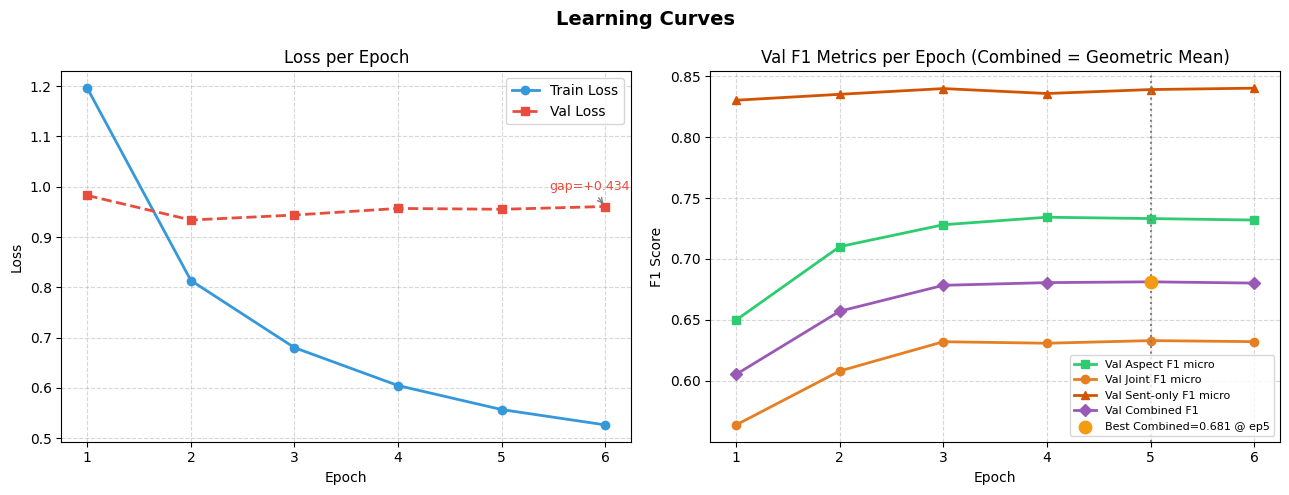

⚠️  Overfit: gap=0.434 — đang dùng dropout=0.3, lr=1e-05, best checkpoint đã được reload trước khi test.

Metrics summary:
Split  aspect_precision_micro  aspect_recall_micro  aspect_f1_micro  joint_precision_micro  joint_recall_micro  joint_f1_micro  sent_f1_micro   loss
  Dev                  0.7020               0.7671           0.7331                 0.6062              0.6624          0.6330         0.8390 0.9551
 Test                  0.7077               0.7645           0.7350                 0.6076              0.6564          0.6311         0.8237 0.9927


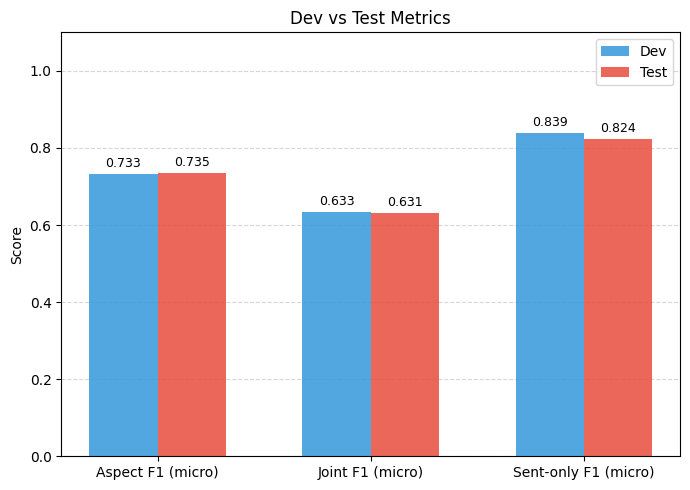

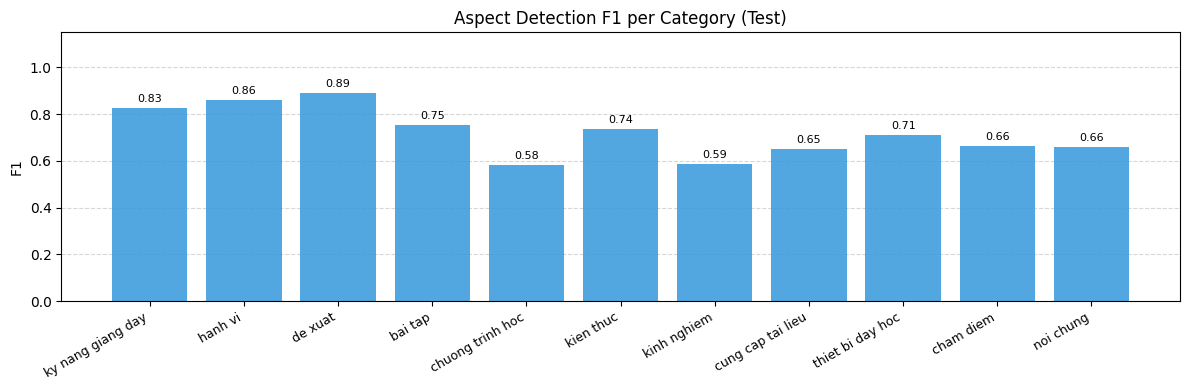

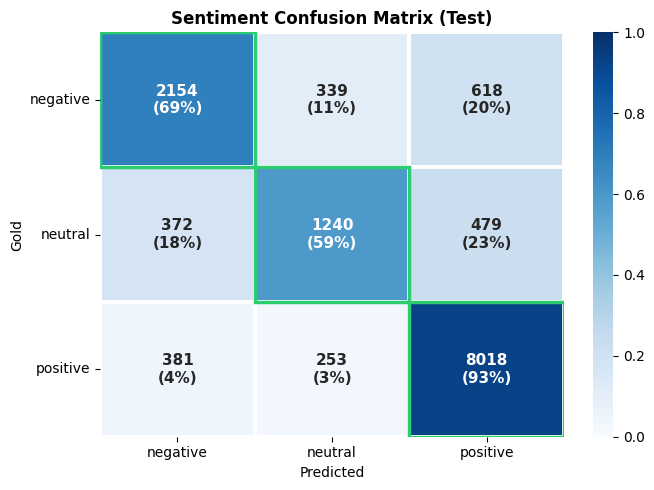


Per-class Sentiment-only (Test, gold aspect present):
              precision    recall  f1-score   support

    negative       0.74      0.69      0.72      3111
     neutral       0.68      0.59      0.63      2091
    positive       0.88      0.93      0.90      8652

    accuracy                           0.82     13854
   macro avg       0.77      0.74      0.75     13854
weighted avg       0.82      0.82      0.82     13854



In [21]:
# ── 1. Learning curves (overfit / underfit) ───────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Learning Curves', fontsize=14, fontweight='bold')

epochs = history['epoch']
ax1.plot(epochs, history['train_loss'], 'o-',  color='#3498db', label='Train Loss', lw=2)
ax1.plot(epochs, history['val_loss'],   's--', color='#e74c3c', label='Val Loss',   lw=2)
gap = history['val_loss'][-1] - history['train_loss'][-1]
ax1.annotate(f'gap={gap:+.3f}',
             xy=(epochs[-1], history['val_loss'][-1]),
             xytext=(-40, 12), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9, color='#e74c3c')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('Loss per Epoch')
ax1.legend(); ax1.grid(True, linestyle='--', alpha=0.5); ax1.set_axisbelow(True)

best_epoch = epochs[history['val_combined_f1'].index(max(history['val_combined_f1']))]
best_f1    = max(history['val_combined_f1'])
ax2.plot(epochs, history['val_aspect_f1_micro'], 's-', color='#2ecc71', lw=2, label='Val Aspect F1 micro')
ax2.plot(epochs, history['val_joint_f1_micro'],  'o-', color='#e67e22', lw=2, label='Val Joint F1 micro')
ax2.plot(epochs, history['val_sent_f1_micro'],   '^-', color='#d35400', lw=2, label='Val Sent-only F1 micro')
ax2.plot(epochs, history['val_combined_f1'], 'D-', color='#9b59b6', lw=2, label='Val Combined F1')
ax2.axvline(best_epoch, color='gray', linestyle=':', lw=1.5)
ax2.scatter([best_epoch], [best_f1], color='#f39c12', zorder=5, s=80,
            label=f'Best Combined={best_f1:.3f} @ ep{best_epoch}')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('F1 Score'); ax2.set_title('Val F1 Metrics per Epoch (Combined = Geometric Mean)')
ax2.legend(fontsize=8); ax2.grid(True, linestyle='--', alpha=0.5); ax2.set_axisbelow(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'learning_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

if gap > 0.3:
    print(f"⚠️  Overfit: gap={gap:.3f} — đang dùng dropout={DROPOUT}, lr={LEARNING_RATE}, best checkpoint đã được reload trước khi test.")
elif best_f1 < 0.5:
    print(f"⚠️  Underfit: best_f1={best_f1:.3f} — thử tăng MAX_EPOCHS hoặc giảm LR.")
else:
    print(f"✓  Fit tốt: gap={gap:.3f}, best combined_f1={best_f1:.3f} @ epoch {best_epoch}.")

# ── 2. Dev vs Test metrics bar chart ─────────────────────────────────────
metric_keys = ['aspect_precision_micro', 'aspect_recall_micro', 'aspect_f1_micro', 'joint_precision_micro', 'joint_recall_micro', 'joint_f1_micro', 'sent_f1_micro', 'loss']
summary = pd.DataFrame([
    {'Split': 'Dev',  **{k: round(dev_metrics[k],  4) for k in metric_keys}},
    {'Split': 'Test', **{k: round(test_metrics[k], 4) for k in metric_keys}},
])
print('\nMetrics summary:')
print(summary.to_string(index=False))

plot_keys = ['aspect_f1_micro', 'joint_f1_micro', 'sent_f1_micro']
x      = np.arange(len(plot_keys))
width  = 0.32
fig, ax = plt.subplots(figsize=(7, 5))
for i, (split, metrics) in enumerate([('Dev', dev_metrics), ('Test', test_metrics)]):
    scores = [metrics[k] for k in plot_keys]
    bars   = ax.bar(x + (i - 0.5) * width, scores, width,
                    label=split, color=['#3498db','#e74c3c'][i], alpha=0.85)
    ax.bar_label(bars, fmt='%.3f', fontsize=9, padding=3)
ax.set_xticks(x); ax.set_xticklabels(['Aspect F1 (micro)', 'Joint F1 (micro)', 'Sent-only F1 (micro)'], fontsize=10)
ax.set_ylim(0, 1.1); ax.set_ylabel('Score')
ax.set_title('Dev vs Test Metrics')
ax.legend(); ax.yaxis.grid(True, linestyle='--', alpha=0.5); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

# ── 3. Per-category Aspect F1 (Test) ─────────────────────────────────────
per_cat_f1 = [
    sk_f1(test_metrics['asp_gold'][:, i], test_metrics['asp_pred'][:, i], zero_division=0)
    for i in range(NUM_ASPECTS)
]
short_labels = [c.replace('_', ' ') for c in ASPECT_CATEGORIES]

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(short_labels, per_cat_f1, color='#3498db', alpha=0.85)
ax.bar_label(bars, fmt='%.2f', fontsize=8, padding=3)
ax.set_ylim(0, 1.15); ax.set_ylabel('F1')
ax.set_title('Aspect Detection F1 per Category (Test)')
ax.yaxis.grid(True, linestyle='--', alpha=0.5); ax.set_axisbelow(True)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.tight_layout(); plt.show()

# ── 4. Sentiment confusion matrix (Test) ─────────────────────────────────
cm      = confusion_matrix(test_metrics['sen_gold'], test_metrics['sen_pred'],
                           labels=list(range(NUM_POLARITIES)))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
annots  = np.array([[f'{cm[i,j]}\n({cm_norm[i,j]:.0%})' for j in range(NUM_POLARITIES)]
                    for i in range(NUM_POLARITIES)])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_norm, annot=annots, fmt='', cmap='Blues', ax=ax,
            xticklabels=POLARITIES, yticklabels=POLARITIES,
            vmin=0, vmax=1, linewidths=1.5, linecolor='white',
            annot_kws={'size': 11, 'weight': 'bold'})
for i in range(NUM_POLARITIES):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False, edgecolor='#2ecc71', lw=2.5))
ax.set_title('Sentiment Confusion Matrix (Test)', fontsize=12, fontweight='bold')
ax.set_ylabel('Gold'); ax.set_xlabel('Predicted')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout(); plt.show()

# ── 5. Per-class sentiment-only report ──────────────────────────────────
from sklearn.metrics import classification_report
print('\nPer-class Sentiment-only (Test, gold aspect present):')
print(classification_report(
    test_metrics['sen_gold'], test_metrics['sen_pred'],
    target_names=POLARITIES, zero_division=0))


## 9. Inference

In [22]:
def find_best_threshold(model, loader, thresholds=None):
    """Tune threshold per-category trên validation set."""
    if thresholds is None:
        thresholds = [0.3, 0.4, 0.5, 0.6]
    
    model.eval()
    all_asp_gold, all_asp_logits = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            token_type_ids = batch['token_type_ids'].to(device)
            _, asp_logits, _ = model(input_ids, attention_mask, token_type_ids)
            all_asp_logits.append(torch.sigmoid(asp_logits).cpu().numpy())
            all_asp_gold.append(batch['aspect_labels'].numpy())
    
    logits = np.vstack(all_asp_logits)   # (N, NUM_ASPECTS)
    gold   = np.vstack(all_asp_gold)     # (N, NUM_ASPECTS)
    
    from sklearn.metrics import f1_score
    best_thresh = 0.5
    best_f1     = 0.0
    for t in thresholds:
        preds = (logits > t).astype(int)
        f1    = f1_score(gold, preds, average='micro', zero_division=0)
        print(f'  threshold={t:.2f} → aspect_f1={f1:.4f}')
        if f1 > best_f1:
            best_f1, best_thresh = f1, t
    print(f'  Best threshold: {best_thresh} (f1={best_f1:.4f})')
    return best_thresh


def predict(text, model, tokenizer, threshold=0.5):
    model.eval()
    text = preprocess_text(text)
    enc = tokenizer(text, max_length=MAX_SEQ_LENGTH, padding='max_length',
                    truncation=True, return_tensors='pt')
    with torch.no_grad():
        _, asp_logits, sent_logits = model(
            enc['input_ids'].to(device),
            enc['attention_mask'].to(device),
            enc['token_type_ids'].to(device),
        )
    asp_probs  = torch.sigmoid(asp_logits).squeeze().cpu().numpy()   # (15,)
    sent_pred  = torch.argmax(sent_logits, dim=-1).squeeze().cpu().numpy()  # (15,)

    results = []
    for i, (prob, cat) in enumerate(zip(asp_probs, ASPECT_CATEGORIES)):
        if prob >= threshold:
            # Chỉ lấy sentiment ở aspect được detect — mask phần còn lại
            results.append({
                'category':   cat,
                'sentiment':  ID2POL[int(sent_pred[i])],
                'confidence': round(float(prob), 3),
            })
    return results


# Tune threshold trên dev set
print('Tuning threshold on dev set...')
best_thresh = find_best_threshold(model, dev_loader,
                                  thresholds=[0.2, 0.3, 0.4, 0.5, 0.6])

# Test inference
test_sentences = [
    'Thầy dạy rất hay nhưng phòng học quá nóng.',
    'Giảng viên nhiệt tình, tài liệu đầy đủ.',
    'Bài kiểm tra quá khó và không công bằng.',
]
print()
for sent in test_sentences:
    result = predict(sent, model, tokenizer, threshold=best_thresh)
    print(f'Input : {sent}')
    for r in result:
        print(f'  → [{r["category"]}] {r["sentiment"]} (conf={r["confidence"]})')
    print()


Tuning threshold on dev set...
  threshold=0.20 → aspect_f1=0.6483
  threshold=0.30 → aspect_f1=0.7002
  threshold=0.40 → aspect_f1=0.7241
  threshold=0.50 → aspect_f1=0.7331
  threshold=0.60 → aspect_f1=0.7359
  Best threshold: 0.6 (f1=0.7359)

Input : Thầy dạy rất hay nhưng phòng học quá nóng.
  → [ky_nang_giang_day] positive (conf=0.948)
  → [thiet_bi_day_hoc] positive (conf=0.799)

Input : Giảng viên nhiệt tình, tài liệu đầy đủ.
  → [hanh_vi] positive (conf=0.863)
  → [cung_cap_tai_lieu] positive (conf=0.984)

Input : Bài kiểm tra quá khó và không công bằng.
  → [bai_tap] negative (conf=0.97)
  → [cham_diem] negative (conf=0.73)

